In [1]:
# %%capture
# !pip install transformers datasets evaluate emoji==2.2.0 optimum onnx onnxruntime

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset 1 EDA — tweet_emotions.csv

Shape: (40000, 3)
tweet_id      int64
sentiment    object
content      object
dtype: object
     tweet_id   sentiment                                            content
0  1956967341       empty  @tiffanylue i know  i was listenin to bad habi...
1  1956967666     sadness  Layin n bed with a headache  ughhhh...waitin o...
2  1956967696     sadness                Funeral ceremony...gloomy friday...
3  1956967789  enthusiasm               wants to hang out with friends SOON!
4  1956968416     neutral  @dannycastillo We want to trade with someone w...

Missing values:
 tweet_id     0
sentiment    0
content      0
dtype: int64

Sentiment counts:
 sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


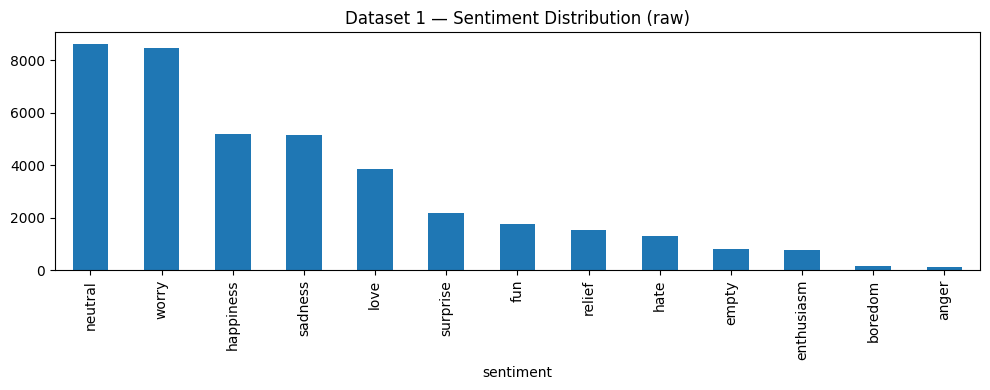

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final Project/tweet_emotions.csv')

print("Shape:", df1.shape)
print(df1.dtypes)
print(df1.head())
print("\nMissing values:\n", df1.isnull().sum())
print("\nSentiment counts:\n", df1['sentiment'].value_counts())

df1['sentiment'].value_counts().plot(kind='bar', figsize=(10,4), title='Dataset 1 — Sentiment Distribution (raw)')
plt.tight_layout()
plt.show()

# Dataset 2 EDA — emotions.csv

Shape: (416809, 2)
text     object
label     int64
dtype: object
                                                text  label
0      i just feel really helpless and heavy hearted      4
1  ive enjoyed being able to slouch about relax a...      0
2  i gave up my internship with the dmrg and am f...      4
3                         i dont know i feel so lost      0
4  i am a kindergarten teacher and i am thoroughl...      4

Missing values:
 text     0
label    0
dtype: int64

Label counts:
 label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64


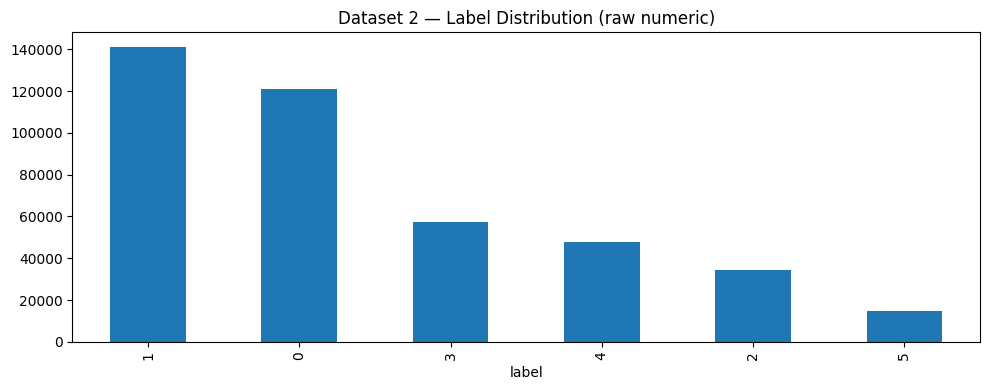

In [4]:
df2_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final Project/emotions.csv')

print("Shape:", df2_raw.shape)
print(df2_raw.dtypes)
print(df2_raw.head())
print("\nMissing values:\n", df2_raw.isnull().sum())
print("\nLabel counts:\n", df2_raw['label'].value_counts())

# Numeric label meanings: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
df2_raw['label'].value_counts().plot(kind='bar', figsize=(10,4), title='Dataset 2 — Label Distribution (raw numeric)')
plt.tight_layout()
plt.show()

Dataset 2 after mapping:
sentiment
happy      141067
sad        121187
angry       57317
fearful     47712
Name: count, dtype: int64


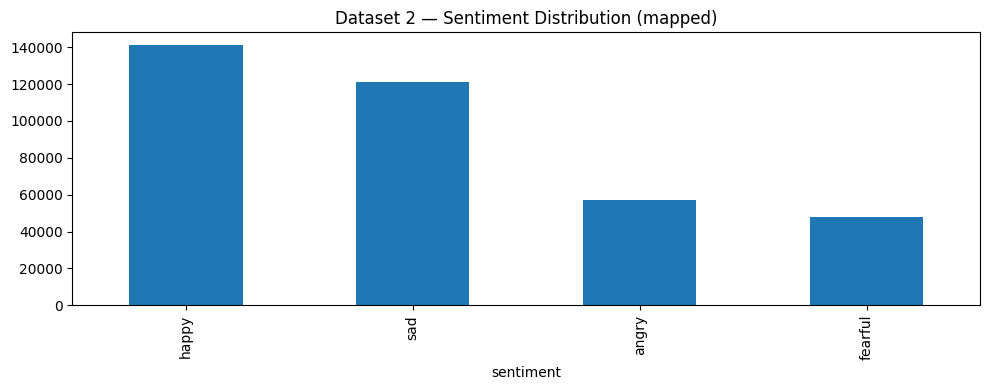

In [5]:
# Map numeric labels to named emotions matching our consolidated classes.
# love (2) and surprise (5) are dropped — they don't fit our class set.
emotions2_mapping = {
    0: 'sad',
    1: 'happy',
    3: 'angry',
    4: 'fearful',
}

df2 = df2_raw[df2_raw['label'].isin(emotions2_mapping.keys())].copy()
df2['sentiment'] = df2['label'].map(emotions2_mapping)
df2 = df2.rename(columns={'text': 'content'})[['content', 'sentiment']]
df2 = df2.reset_index(drop=True)

print("Dataset 2 after mapping:")
print(df2['sentiment'].value_counts())

df2['sentiment'].value_counts().plot(kind='bar', figsize=(10,4), title='Dataset 2 — Sentiment Distribution (mapped)')
plt.tight_layout()
plt.show()

# Cleaning — Dataset 1

In [6]:
# Drop tweet_id, not needed for modeling
df1 = df1.drop(columns=['tweet_id']).reset_index(drop=True)
print("df1 shape:", df1.shape)

df1 shape: (40000, 2)


# Evaluating "Empty" Emotion — Dataset 1

In [7]:
from IPython.display import HTML

empty_tweets = df1[df1['sentiment'] == 'empty']['content'].head(20).reset_index(drop=True)

HTML(empty_tweets.to_frame().style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal',
        'max-width': '600px'
    })
    .set_table_styles([{
        'selector': 'td',
        'props': [('max-width', '600px'), ('word-wrap', 'break-word')]
    }])
    .to_html()
)

,content
0,@tiffanylue i know i was listenin to bad habit earlier and i started freakin at his part =[
1,@creyes middle school and elem. High schools will remain open for those who need credits to graduate. Cali is broken
2,@djmicdamn hey yu lil fucker i textd yu
3,@softtouchme just answered you- never learned how to write in French- just basic stuff-
4,Have a headache I'm going to bed. Goodnight!
5,@DymeDiva23 Nite. Now I'm up n bored as opposed to almost sleep frm b 4
6,"@TheTombert i was watching Harpers Island, lol... there was no vodka involved"
7,@tarng Trudy's off Burnet...the one up north that no one goes to
8,@msz_rockstar umm how bout em?..aint get 2 see da game but i see dey survived anotha game of da series due to notin but Lebron im guessin
9,I need to be sleeping.. But i'm not even tired..


# Consolidating Emotions — Dataset 1

In [8]:
# Drop emotions not included in our class set
drop_labels = ['surprise', 'love', 'relief', 'boredom', 'empty']
df1 = df1[~df1['sentiment'].isin(drop_labels)]

emotion_mapping = {
    'happiness':  'happy',
    'fun':        'happy',
    'enthusiasm': 'happy',
    'sadness':    'sad',
    'anger':      'angry',
    'hate':       'angry',
    'worry':      'fearful',
    'neutral':    'neutral',
}

df1['sentiment'] = df1['sentiment'].map(emotion_mapping)
df1 = df1.dropna(subset=['sentiment']).reset_index(drop=True)

print("Dataset 1 after consolidation:")
print(df1['sentiment'].value_counts())

Dataset 1 after consolidation:
sentiment
neutral    8638
fearful    8459
happy      7744
sad        5165
angry      1433
Name: count, dtype: int64


# Combine Datasets

Combined before sampling: (398722, 2)
sentiment
happy      148811
sad        126352
angry       58750
fearful     56171
neutral      8638
Name: count, dtype: int64

After sampling: (40000, 2)
sentiment
happy      14929
sad        12676
angry       5894
fearful     5635
neutral      866
Name: count, dtype: int64


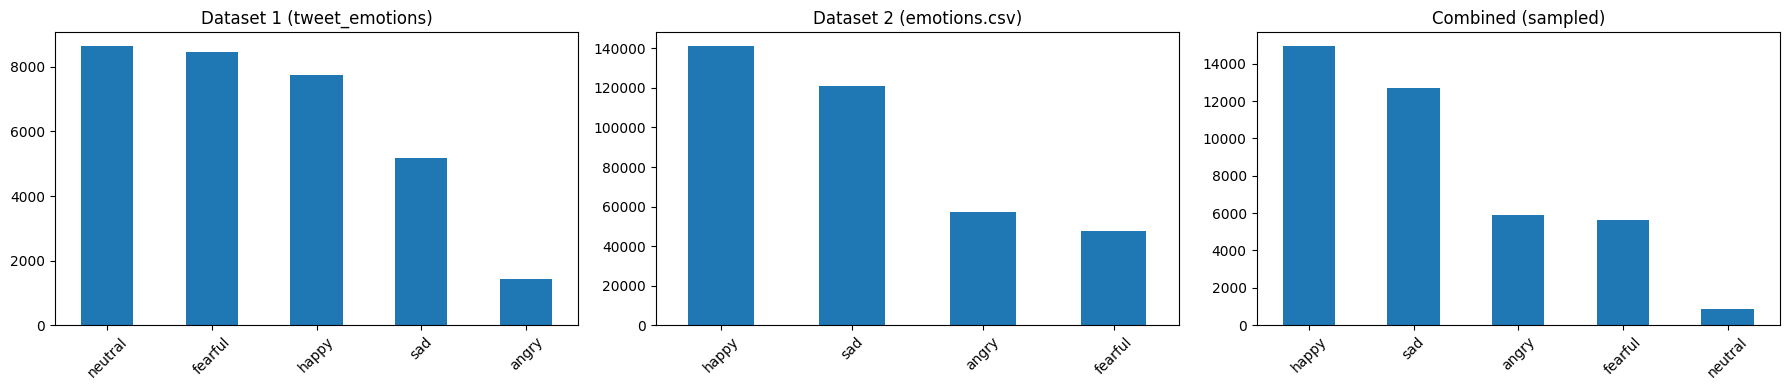

In [9]:
# Note: emotions.csv is general text, not tweets. We still include it because
# the extra data on sad/happy/angry/fearful outweighs the domain mismatch,
# and BERTweet's pretraining gives it enough robustness to handle both.
df = pd.concat([df1, df2], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined before sampling:", df.shape)
print(df['sentiment'].value_counts())

# Sample to a manageable size — keeps class balance via stratify
from sklearn.model_selection import train_test_split

df, _ = train_test_split(df, train_size=40000, random_state=42, stratify=df['sentiment'])
df = df.reset_index(drop=True)

print("\nAfter sampling:", df.shape)
print(df['sentiment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df1['sentiment'].value_counts().plot(kind='bar', ax=axes[0], title='Dataset 1 (tweet_emotions)')
df2['sentiment'].value_counts().plot(kind='bar', ax=axes[1], title='Dataset 2 (emotions.csv)')
df['sentiment'].value_counts().plot(kind='bar', ax=axes[2], title='Combined (sampled)')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Class Imbalance Decision
# The combined dataset still shows imbalance but is much improved by the
# addition of emotions.csv. We continue to use class_weight='balanced'
# at training time rather than downsampling to preserve all available data.

# Text Preprocessing

In [11]:
import re

# clean_for_tfidf    — aggressive clean for the TF-IDF baseline
# clean_for_bertweet — minimal normalisation matching BERTweet pretraining:

def clean_for_tfidf(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_bertweet(text):
    text = re.sub(r'@\w+', '@USER', text)
    text = re.sub(r'http\S+|www\S+', 'HTTPURL', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_content']    = df['content'].apply(clean_for_tfidf)
df['bertweet_content'] = df['content'].apply(clean_for_bertweet)

print(df[['content', 'clean_content', 'bertweet_content']].head(3))

                                             content  \
0  i feel like my requests are unimportant that i...   
1  i leave roller derby practice feeling invigora...   
2                                    Guess not today   

                                       clean_content  \
0  i feel like my requests are unimportant that i...   
1  i leave roller derby practice feeling invigora...   
2                                    guess not today   

                                    bertweet_content  
0  i feel like my requests are unimportant that i...  
1  i leave roller derby practice feeling invigora...  
2                                    Guess not today  


# Encode Labels

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", mapping)

Label mapping: {'angry': np.int64(0), 'fearful': np.int64(1), 'happy': np.int64(2), 'neutral': np.int64(3), 'sad': np.int64(4)}


# Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

y = df['label']

# TF-IDF baseline uses aggressively cleaned text
X_tfidf = df['clean_content']
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# BERTweet uses minimally normalised text (same split via same seed + stratify)
X_bert = df['bertweet_content']
X_train_bert, X_test_bert, _, _ = train_test_split(
    X_bert, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train_bert)}, Test: {len(X_test_bert)}")

Train: 32000, Test: 8000


# Vectorize with TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf_vec = tfidf.fit_transform(X_train_tfidf)
X_test_tfidf_vec  = tfidf.transform(X_test_tfidf)

print("Train shape:", X_train_tfidf_vec.shape)
print("Test shape: ", X_test_tfidf_vec.shape)

Train shape: (32000, 10000)
Test shape:  (8000, 10000)


# Train Logistic Regression

In [15]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf_vec, y_train)
print("LR training complete.")

# Wrap TF-IDF + LR into a Pipeline for single-call inference
lr_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('lr',    lr_model),
])

pipeline_path = '/content/drive/MyDrive/Colab Notebooks/Final Project/lr_pipeline.pkl'
with open(pipeline_path, 'wb') as f:
    pickle.dump(lr_pipeline, f)
print(f"LR pipeline saved → {pipeline_path}")

# Sanity check
with open(pipeline_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)
sample_pred = loaded_pipeline.predict(["i feel so happy today"])
print("Pipeline sanity check:", le.inverse_transform(sample_pred))

LR training complete.
LR pipeline saved → /content/drive/MyDrive/Colab Notebooks/Final Project/lr_pipeline.pkl
Pipeline sanity check: ['happy']


# Evaluate Logistic Regression

              precision    recall  f1-score   support

       angry       0.88      0.89      0.88      1179
     fearful       0.80      0.82      0.81      1127
       happy       0.95      0.92      0.93      2986
     neutral       0.31      0.76      0.44       173
         sad       0.94      0.87      0.90      2535

    accuracy                           0.88      8000
   macro avg       0.78      0.85      0.79      8000
weighted avg       0.90      0.88      0.89      8000



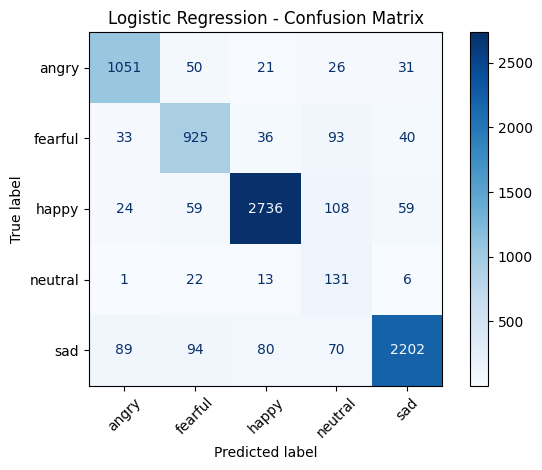

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = lr_model.predict(X_test_tfidf_vec)
class_names = [str(c) for c in le.classes_]

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score
baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.8806


=================================================

In [18]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_bert.tolist(), y_train.tolist(),
    test_size=0.1, random_state=42, stratify=y_train.tolist()
)

train_ds = Dataset.from_dict({'text': X_tr,                 'label': y_tr})
val_ds   = Dataset.from_dict({'text': X_val,                'label': y_val})
test_ds  = Dataset.from_dict({'text': X_test_bert.tolist(), 'label': y_test.tolist()})

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 28800, Val: 3200, Test: 8000


In [19]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/bertweet-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize,   batched=True)
test_ds  = test_ds.map(tokenize,  batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Map:   0%|          | 0/28800 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [20]:
from transformers import AutoModelForSequenceClassification

label2id = {str(label): int(idx) for label, idx in zip(le.classes_, le.transform(le.classes_))}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

In [22]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./emotion_bertweet",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    warmup_steps=200,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.980900,0.248510,0.914062
2,0.225600,0.190665,0.925000
3,0.157800,0.198172,0.930000
4,0.131700,0.206007,0.927188
5,0.108700,0.206065,0.930312
6,0.100600,0.207957,0.927813


TrainOutput(global_step=5400, training_loss=0.2326179094667788, metrics={'train_runtime': 4053.724, 'train_samples_per_second': 42.627, 'train_steps_per_second': 1.332, 'total_flos': 1.13667037544448e+16, 'train_loss': 0.2326179094667788, 'epoch': 6.0})

              precision    recall  f1-score   support

       angry       0.92      0.94      0.93      1179
     fearful       0.86      0.86      0.86      1127
       happy       0.97      0.98      0.97      2986
     neutral       0.50      0.40      0.45       173
         sad       0.95      0.94      0.95      2535

    accuracy                           0.93      8000
   macro avg       0.84      0.83      0.83      8000
weighted avg       0.93      0.93      0.93      8000



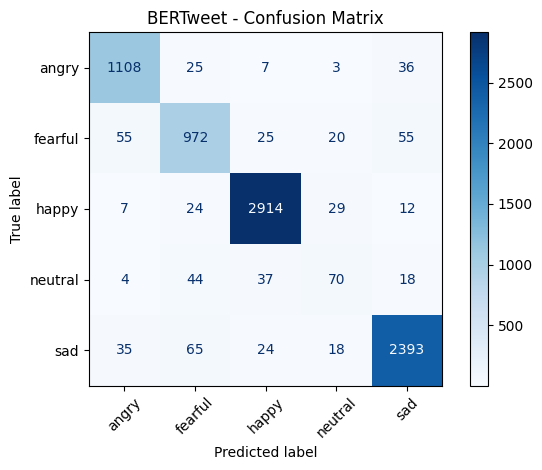

BERTweet Accuracy:                    0.9321
Improvement over Logistic Regression: +0.0515

BERTweet model saved → /content/drive/MyDrive/Colab Notebooks/Final Project/bertweet_emotion_e6


Device set to use cuda:0


BERTweet pipeline pickled → /content/drive/MyDrive/Colab Notebooks/Final Project/bertweet_pipeline_e6.pkl

Sanity check:
  '@USER i am so incredibly happy today HTTPURL'            → happy (1.00)
  'feeling empty and hopeless, nothing matters'             → sad (1.00)
  "this is making me so angry i can't even"                 → angry (0.99)


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pickle

predictions  = trainer.predict(test_ds)
y_pred_bert  = np.argmax(predictions.predictions, axis=-1)
y_true       = predictions.label_ids

class_names = [str(c) for c in le.classes_]
print(classification_report(y_true, y_pred_bert, target_names=class_names))

cm   = confusion_matrix(y_true, y_pred_bert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('BERTweet - Confusion Matrix')
plt.tight_layout()
plt.show()

bert_accuracy = accuracy_score(y_true, y_pred_bert)
print(f"BERTweet Accuracy:                    {bert_accuracy:.4f}")
print(f"Improvement over Logistic Regression: +{bert_accuracy - baseline_accuracy:.4f}")

# ── Save model + tokenizer to Drive ──────────────────────────────────────
save_path = '/content/drive/MyDrive/Colab Notebooks/Final Project/bertweet_emotion_e6'
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"\nBERTweet model saved → {save_path}")

# ── Pickle HuggingFace pipeline for single-call inference ────────────────
from transformers import pipeline as hf_pipeline

emotion_pipe = hf_pipeline(
    "text-classification",
    model=save_path,
    tokenizer=save_path,
    device=0   # use -1 for CPU
)

hf_pipe_path = '/content/drive/MyDrive/Colab Notebooks/Final Project/bertweet_pipeline_e6.pkl'
with open(hf_pipe_path, 'wb') as f:
    pickle.dump(emotion_pipe, f)
print(f"BERTweet pipeline pickled → {hf_pipe_path}")

# ── Sanity check ─────────────────────────────────────────────────────────
test_tweets = [
    "@USER i am so incredibly happy today HTTPURL",
    "feeling empty and hopeless, nothing matters",
    "this is making me so angry i can't even",
]
print("\nSanity check:")
for tweet, result in zip(test_tweets, emotion_pipe(test_tweets)):
    print(f"  {tweet[:55]!r:57} → {result['label']} ({result['score']:.2f})")

In [24]:
# Model is already saved and ready to share at save_path.
# Teammates load it with:
#
#   pip install transformers torch
#
#   from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
#
#   emotion_pipe = pipeline(
#       "text-classification",
#       model="/path/to/bertweet_emotion",
#       tokenizer="/path/to/bertweet_emotion",
#   )
#   emotion_pipe(["i feel so happy today"])

print(f"Model saved at: {save_path}")
print("Share the bertweet_emotion folder from Google Drive with my teammates.")

Model saved at: /content/drive/MyDrive/Colab Notebooks/Final Project/bertweet_emotion_e6
Share the bertweet_emotion folder from Google Drive with my teammates.


Predicted emotion: happy (98.9% confidence)


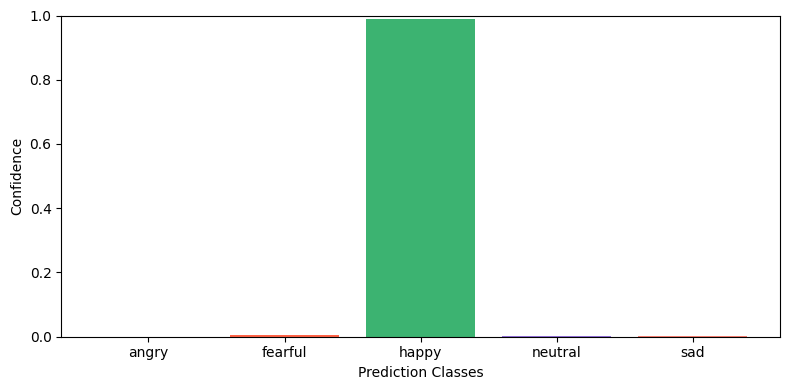

In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def predict_emotion(text):
    # Normalise for BERTweet
    import re
    text = re.sub(r'@\w+', '@USER', text)
    text = re.sub(r'http\S+|www\S+', 'HTTPURL', text)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to("cuda")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

    predicted_idx = np.argmax(probs)
    predicted_label = id2label[predicted_idx]
    confidence = probs[predicted_idx]

    print(f"Predicted emotion: {predicted_label} ({confidence*100:.1f}% confidence)")

    labels = [id2label[i] for i in range(len(id2label))]
    colors = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple', 'salmon']

    plt.figure(figsize=(8, 4))
    plt.bar(labels, probs, color=colors[:len(labels)])
    plt.ylabel('Confidence')
    plt.xlabel('Prediction Classes')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# ── Try it out ────────────────────────────────────────────────────────────
predict_emotion("I just got the best news of my life!")